In [1]:
using LinearAlgebra
using Statistics
using Random
using Distributions
using Combinatorics
using NPZ
using JLD2
using Base.Threads
using PyPlot, JSON, LaTeXStrings

# ----------------------------------------------------------------------
# Load the local module (same folder as this script)
# ----------------------------------------------------------------------
include(joinpath(@__DIR__, "../../../src/qgp_machinery.jl"))
import .QuantumGPs

# ----------------------------------------------------------------------
# Shot-noise samplers (projective Pauli measurements)
# ----------------------------------------------------------------------

"""
    sample_pauli_mean(μ, shots)

Simulate `shots` projective measurements of a Pauli observable with true
expectation value `μ ∈ [-1,1]` (outcomes ±1), and return the sample mean.
"""
@inline function sample_pauli_mean(μ::Real, shots)
    if shots == Inf
        return μ
    end
    shots <= 0 && error("shots must be positive, not $shots")
    μc = clamp(Float64(μ), -1.0, 1.0)
    p = 0.5 * (1 + μc)
    k = rand(Binomial(shots, p))
    return (2k - shots) / shots
end

"""
    pauli_mean_var(μ, shots)

Variance of the sample mean produced by `sample_pauli_mean`.
"""
@inline function pauli_mean_var(μ::Real, shots)
    if shots == Inf
        return 0.0
    end
    shots <= 0 && error("shots must be positive")
    μc = clamp(Float64(μ), -1.0, 1.0)
    return (1 - μc^2) / shots
end

# ----------------------------------------------------------------------
# Kernel noise model used in this script (sum-of-dl i.i.d. terms)
# ----------------------------------------------------------------------

function noisy_sum_from_S(S_true::Real, dl::Int, n::Int;
                          model::Symbol = :upper_bound,
                          rng=Random.default_rng())
    σ2 = if model == :upper_bound
        dl / n
    elseif model == :equal_terms
        μbar = S_true / dl
        (dl / n) * (1 - μbar^2)
    else
        error("model must be :upper_bound or :equal_terms")
    end
    return rand(rng, Normal(S_true, sqrt(σ2)))
end

"""
    add_noise_2_kernel_sum(K, dl, nshots)

Apply the `noisy_sum_from_S` model entrywise to a symmetric kernel matrix.
Returns `(ker, ker_vars)`.

Note: This is *not* the same noise model as `QuantumGPs.add_noise_2_kernel`.
"""
function add_noise_2_kernel_sum(K, dl, nshots)
    nshots <= 0 && error("nshots must be positive")
    d = size(K, 1)
    @assert size(K, 2) == d

    ker = Matrix{Float64}(undef, d, d)
    ker_vars = fill(dl / nshots, (d, d))

    for i in 1:d
        @inbounds ker[i, i] = noisy_sum_from_S(K[i, i], dl, nshots)
        for j in (i + 1):d
            @inbounds begin
                ovp = noisy_sum_from_S(K[i, j], dl, nshots)
                ker[i, j] = ovp
                ker[j, i] = ovp
            end
        end
    end

    return ker, ker_vars
end

# ----------------------------------------------------------------------
# Observable noise model: estimate ⟨XX+YY+ZZ⟩ via SWAP
# ----------------------------------------------------------------------

"""
    noisy_xxyyzz_from_true(true_xxyyzz, nshots)

Shot-noise a theoretical value of ⟨XX+YY+ZZ⟩ assuming it is obtained from SWAP via:
    XX+YY+ZZ = 2*SWAP - 1

Model: k0 ~ Binomial(nshots, p0) with p0 = (1+⟨SWAP⟩)/2.
Return noisy estimate of ⟨XX+YY+ZZ⟩.
"""
function noisy_xxyyzz_from_true(true_xxyyzz::Real, nshots::Int; rng::AbstractRNG=Random.default_rng())
    nshots > 0 || throw(ArgumentError("nshots must be positive, got $nshots"))
    if nshots == Inf
        return true_xxyyzz
    end

    s_true = (true_xxyyzz + 1) / 2               # ⟨SWAP⟩
    s_true = clamp(Float64(s_true), -1.0, 1.0)

    p0 = (1 + s_true) / 2                        # Prob(ancilla=0)
    k0 = rand(rng, Binomial(nshots, p0))

    s_hat = 2 * (k0 / nshots) - 1                # noisy ⟨SWAP⟩
    return 2 * s_hat - 1                         # noisy ⟨XX+YY+ZZ⟩
end

"""
    xxyyzz_shot_se_from_true(true_xxyyzz, nshots)

Standard error (1σ) for the estimator of ⟨XX+YY+ZZ⟩ under the same model.
Uses Var(ŝ)= (1 - s^2)/N for SWAP and scales by the factor 2.
"""
function xxyyzz_shot_se_from_true(true_xxyyzz::Real, nshots)
    nshots > 0 || throw(ArgumentError("nshots must be positive, got $nshots"))
    if nshots == Inf
        return 0.0
    end
    s_true = clamp((true_xxyyzz + 1) / 2, -1.0, 1.0)
    return 2 * sqrt((1 - s_true^2) / nshots)
end

# ----------------------------------------------------------------------
# GP entry point (adapted to use QuantumGPs.qgp_fit_predict)
# ----------------------------------------------------------------------

"""
    gp_predict_b2b4(n, true_outputs, true_overlaps2, true_overlaps4,
                   ntp, nshots_obs, nshots_ker; verbose=false)

Build a noisy kernel as (b2 + b4), then run a *single* GP using the shared
`QuantumGPs.qgp_fit_predict` routine.

Returns:
  μ_pred, σ_pred, y_obs, σ_obs, train_idxs, test_idxs
"""
function gp_predict_b2b4(
    n::Int,
    true_outputs::AbstractVector,
    true_overlaps2::AbstractMatrix,
    true_overlaps4::AbstractMatrix,
    ntp::Int,
    nshots_obs,
    nshots_ker;
    verbose::Bool = false,
)

    dsize = length(true_outputs)
    @assert size(true_overlaps2, 1) >= dsize
    @assert size(true_overlaps4, 2) >= dsize

    # Base kernels (exact overlaps restricted to dataset size)
    K2 = @view true_overlaps2[1:dsize, 1:dsize]
    K4 = @view true_overlaps4[1:dsize, 1:dsize]

    # Noisy kernel estimates
    dl_2 = binomial(2n, 2)
    dl_4 = binomial(2n, 4)
    ker2, ker_vars2 = add_noise_2_kernel_sum(K2, dl_2, nshots_ker)
    ker4, ker_vars4 = add_noise_2_kernel_sum(K4, dl_4, nshots_ker)

    # Apply kernel scaling (unchanged from your tmp2)
    kernel_factor2 = 2 * factorial(2) / (2n)^2
    kernel_factor4 = factorial(4) / (2n)^4

    ker2 .*= kernel_factor2
    ker_vars2 .*= kernel_factor2^2

    ker4 .*= kernel_factor4
    ker_vars4 .*= kernel_factor4^2

    ker = ker2 + ker4
    ker_vars = ker_vars2 + ker_vars4

    # Training / test split (unchanged)
    train_idxs = [dsize]
    test_idxs  = setdiff(collect(1:dsize), train_idxs)

    # Noisy observations on training points
    σ_obs  = [xxyyzz_shot_se_from_true(true_outputs[i], nshots_obs) for i in train_idxs]
    σ²_obs = σ_obs .^ 2
    y_obs  = [noisy_xxyyzz_from_true(true_outputs[i], nshots_obs) for i in train_idxs]

    if verbose
        @info "Running GP regression via QuantumGPs.qgp_fit_predict" dsize ntp nshots_obs nshots_ker
    end

    # Use shared GP routine
    # - we pass obs noise separately (do NOT bake into the kernel diagonal)
    # - ker_σ² is treated as an estimate of kernel uncertainty and added to predictive variance
    fit = QuantumGPs.qgp_fit_predict(
        ker,
        y_obs,
        train_idxs;
        obs_σ² = σ²_obs,
        ker_σ² = mean(diag(ker_vars)),
        ker_ε = 1e-20,
        psd_method = :shift,
    )

    μ_pred = fit.mean  # [test_idxs]
    σ_pred = fit.std   # [test_idxs]

    return μ_pred, σ_pred, y_obs, σ_obs, train_idxs, test_idxs
end


gp_predict_b2b4

In [2]:
# load data

n = 50
d = 2^n
base = "../../data/"

true_outputs_m2     = npzread(joinpath(base, "true_outputs_m2_$(n)q.npy"))
true_outputs_m4     = npzread(joinpath(base, "true_outputs_m4_$(n)q.npy"))
true_overlaps_m2    = npzread(joinpath(base, "true_overlaps_m2_$(n)q.npy"))
true_overlaps_m4    = npzread(joinpath(base, "true_overlaps_m4_$(n)q.npy"));

In [3]:
true_overlaps_m2 *= d 
true_overlaps_m4 *= d ;

In [4]:
true_outputs  = true_outputs_m2 + true_outputs_m4;

In [5]:
ntp = 1
nshots_obs = Int(1e4)
nshots_preds = Int(1e4)

gp_mu, gp_sigma, y_obs, σ_obs, train_idxs, test_idxs =
        gp_predict_b2b4(n, true_outputs, true_overlaps_m2, true_overlaps_m4, ntp, nshots_obs, nshots_preds; verbose = false);

In [6]:
PyPlot.matplotlib.style.use("default")
PyPlot.matplotlib.style.use("../../../config/unified_plots.mplstyle")
plot_args = JSON.parsefile("../../../config/unified_plots.json")

make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

t_list = range(0.05, stop=2, length=length(true_outputs))
outputs = true_outputs

function plot_qgp!(ax, yobs, train_idxs, μ, σ; panel_title="", plot_args=plot_args)
    """
    Plots a generic QGP prediction.
    Assumes `t_list`, `outputs`, and `plot_args` exist in the global scope.
    """
    # 1. True dynamics
    true_line = ax.plot(t_list, outputs; make_kwargs(plot_args["true_function"])...)[1]
                    
    # 2. Training Data
    # Extract the kwargs and dynamically override just the label
    obs_kwargs = make_kwargs(plot_args["observations"])
    obs_kwargs[:label] = "$(length(train_idxs)) $(plot_args["observations"]["label"])" 
    obs_pts = ax.plot(t_list[train_idxs], yobs; obs_kwargs...)[1]
               
    # 3. QGP Prediction
    qgp_band = ax.fill_between(t_list, μ .- σ, μ .+ σ; make_kwargs(plot_args["gp_stds"])...)
    qgp_line = ax.plot(t_list, μ; make_kwargs(plot_args["gp_mean"])...)[1]
    
    if !isempty(panel_title)
        ax.set_title(panel_title)
    end

    legend_handles = [true_line, obs_pts, (qgp_line, qgp_band)]
    legend_labels = [true_line.get_label(), obs_pts.get_label(), qgp_line.get_label()]

    # ax.set_xlabel(plot_args["regression"]["xlabel"])
    ax.set_xlabel(L"J_1/J_2")
    # ax.set_ylabel(L"\langle X_{\frac{n}{2}}X_{\frac{n}{2}+1} + Y_{\frac{n}{2}}Y_{\frac{n}{2}+1} + Z_{\frac{n}{2}}Z_{\frac{n}{2}+1} \rangle")
    ax.set_ylabel(L"2\langle {\rm SWAP}_{\frac{n}{2},\frac{n}{2}+1} \rangle - 1")
    
    
    return ax, legend_handles, legend_labels
end

function plot_qgp(yobs, train_idxs, μ, σ; panel_title="", plot_args=plot_args)
    """
    Creates a new standalone figure, calls plot_qgp!, adds a legend, and returns fig, ax.
    """
    # Create the standalone figure and axis automatically
    fig_width = plot_args["fig_width_inches_half"]
    fig, ax = PyPlot.subplots(figsize=(fig_width, 2))
    
    # Call the core mutating function defined above
    _, legend_handles, legend_labels = plot_qgp!(ax, yobs, train_idxs, μ, σ; panel_title=panel_title, plot_args=plot_args)

    ax.legend(legend_handles, legend_labels, frameon=false)
    
    return fig, ax, legend_handles, legend_labels
end

function save_and_display(fig, filename; 
                          bbox_inches="tight", 
                          pad_inches=0.1,   # 0.1 is standard, use 0.0 for naked matrices
                          transparent=true)
    """
    Handles directory creation, saving, and displaying of a Matplotlib figure.
    """
    out_dir = "../plots"
    
    # Create directory if it doesn't exist
    isdir(out_dir) || mkpath(out_dir)
    
    if true
        filepath = joinpath(out_dir, string(filename))
        fig.savefig(filepath, 
                    bbox_inches=bbox_inches, 
                    pad_inches=pad_inches, 
                    transparent=transparent)
        println("Saved: ", filepath) # Optional: nice feedback in the REPL
    end
    
    display(fig)
end

save_and_display (generic function with 1 method)

Saved: ../plots/alt_xxx_qgp_10000_obs_shots_10000_preds_shots_1ntp.pdf


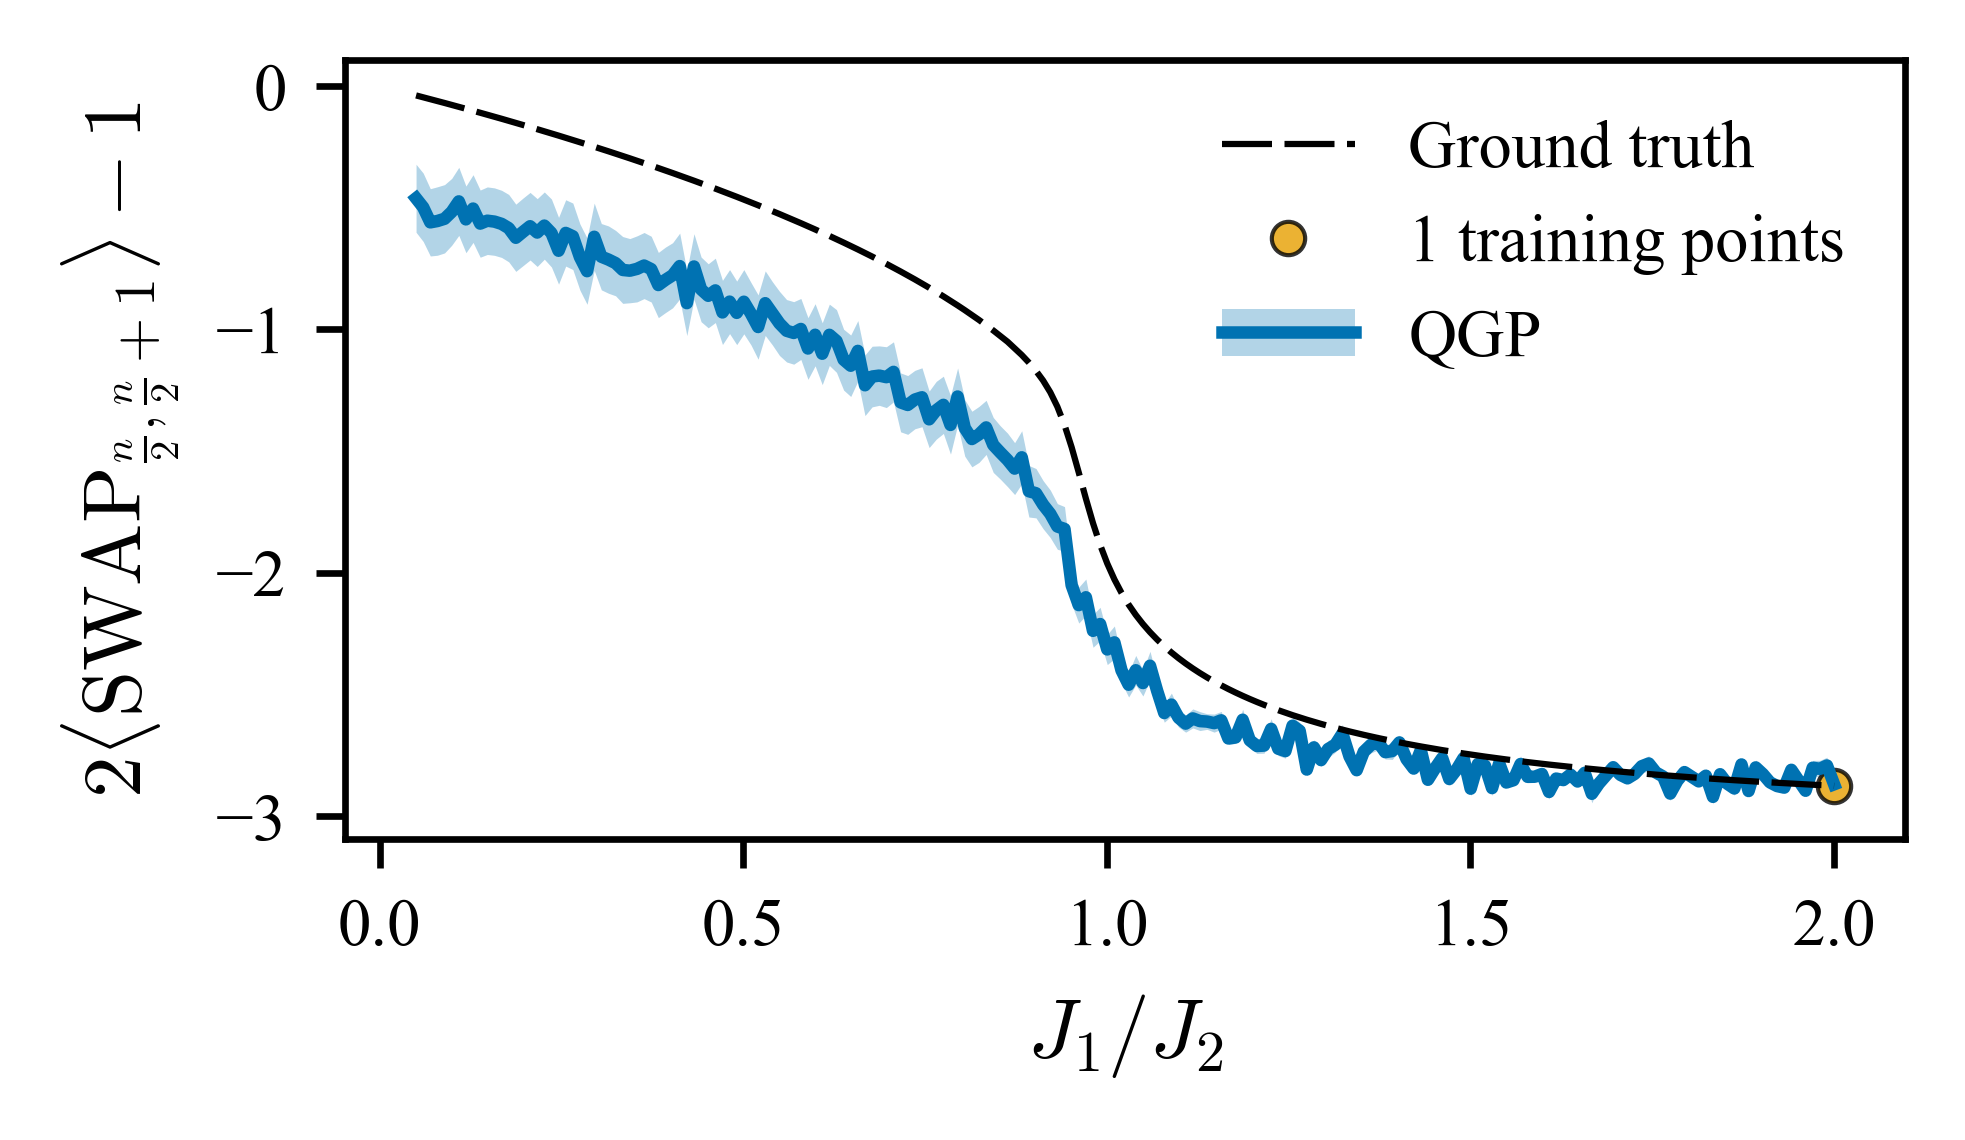

In [7]:
m=2
fig_circle, ax_circle = plot_qgp(y_obs, train_idxs, gp_mu, gp_sigma; 
                   panel_title="")  # "shot noise "*"\$(n_{\\mathrm{s}}^{\\mathrm{obs}}=n_{\\mathrm{s}}^{\\kappa}=10^4)\$"
save_and_display(fig_circle, "alt_xxx_qgp_$(nshots_obs)_obs_shots_$(nshots_preds)_preds_shots_$(length(train_idxs))ntp.pdf")